In [11]:
import torch
from torch import nn, optim
from torchvision import models, transforms, datasets
import random
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import os


In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


In [13]:

train_dir = "F:\\Python\\data\\train"  
val_dir = "F:\\Python\\data\\train"   
test_dir = "F:\\Python\\data\\test"   

classes = ['normal', 'defective']

In [14]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), 
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize using ImageNet mean and std
])


In [ ]:
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(val_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)


batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [16]:
model = models.resnet50(pretrained=True)
# Replace the final layer for binary classification 
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, len(classes))  
model = model.to(device)

# Define loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [26]:
# Training function
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=5):
    best_acc = 0.0
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 30)

        
        model.train()
        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()

            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)

        print(f"Train Loss: {epoch_loss:.4f}, Train Accuracy: {epoch_acc:.4f}")

        
        model.eval()
        val_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                val_corrects += torch.sum(preds == labels)

        val_acc = val_corrects.double() / len(val_loader.dataset)
        print(f"Validation Accuracy: {val_acc:.4f}")

        # Save the best model
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_model.pth")
            print("Best model saved!")

    print("Training complete. Best validation accuracy: {:.4f}".format(best_acc))

In [ ]:
# Train the model
train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=10)

In [ ]:
# Load the best model
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [30]:
# Testing function
def test_model(model, test_loader, classes):
    model.eval()
    test_corrects = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            test_corrects += torch.sum(preds == labels)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    test_acc = test_corrects.double() / len(test_loader.dataset)
    print(f"Test Accuracy: {test_acc:.4f}")
    return all_preds, all_labels
predictions, ground_truth = test_model(model, test_loader, classes)

Test Accuracy: 0.8739


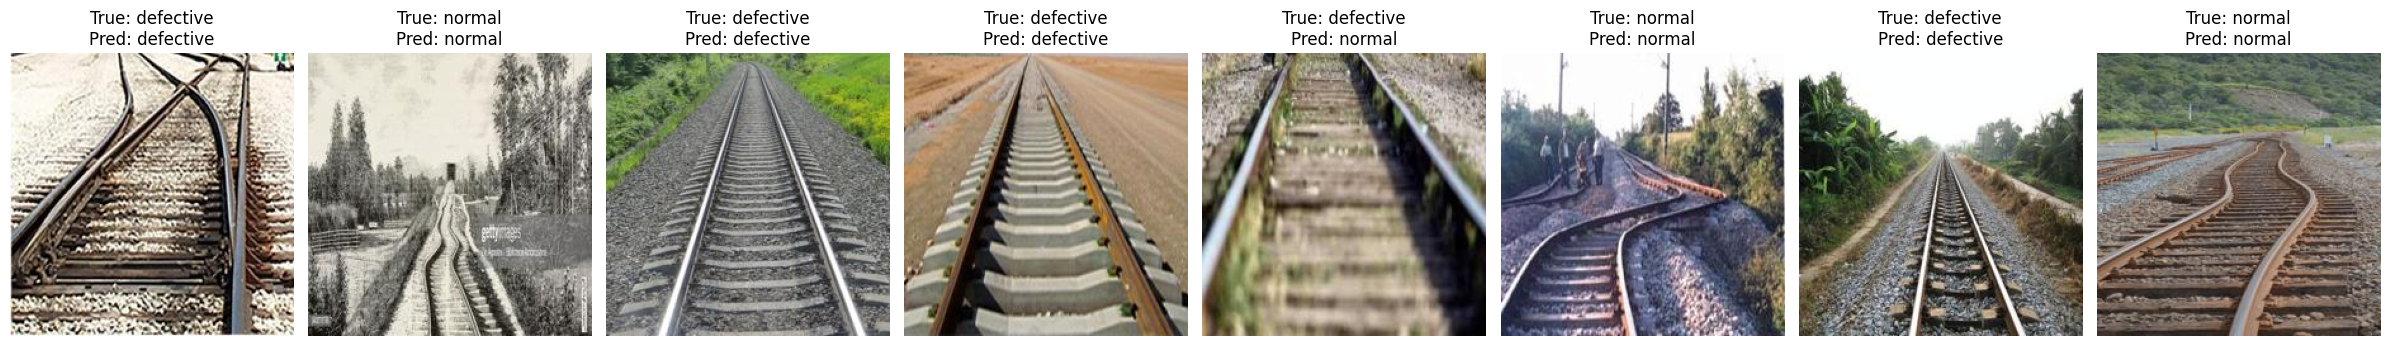

In [ ]:
def visualize_results(model, test_dataset, classes, n=8):
    model.eval()

    total = len(test_dataset)
    if total == 0:
        print("Test dataset is empty.")
        return   
    n = min(n, total)
    indices = random.sample(range(total), n)
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 4))
    if n == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        image, label = test_dataset[idx]
        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model(input_tensor)
            _, pred = torch.max(output, 1)
            pred = pred.item()
        img = image.numpy().transpose(1, 2, 0)
        img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
        img = np.clip(img, 0, 1)

        axes[i].imshow(img)
        axes[i].set_title(f"True: {classes[label]}\nPred: {classes[pred]}")
        axes[i].axis("off")
    plt.tight_layout()
    plt.show()
visualize_results(model, test_dataset, classes)